In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("powerplant_data.csv")

In [7]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [8]:
#AT => temperature
#V => Vaccum
#AP=> pressure
#RH=> Humidity

#PE => Produced energy

In [9]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [10]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [11]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [12]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [13]:
#split our data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [14]:
df.shape

(9568, 5)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [17]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [18]:
train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

### Deep Learning

In [19]:
 # define our ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model = nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        # 2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        #output layer
        nn.Linear(6,1),
    )

    def forward(self,x):
       return self.model(x)

In [20]:
import torch.optim as optim
model=ANN()

#loss,optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [26]:
#train the ANN

train_losses = []
valid_losses=[]
best_val_loss = float("inf")

epochs=100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss of one epoch
    
    for xb,yb in train_loader:
            #xb -> features of one batch
            #yb => labels of one batch
        optimizer.zero_grad()
        outputs = model(xb) #predicted outputs  # forward propagation step ....
        loss = criterion(outputs,yb) # computing our loss
        loss.backward() # back propagation # calculation of gradients
        optimizer.step() #params update

        running_loss+=loss.item() # loss is a tensor value , so we are converting it to python float
    epoch_train_loss = running_loss/ len(train_loader)
    train_losses.append(epoch_train_loss)


    #validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad(): # no gradients compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss = running_val_loss/len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}===> training_loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
    if epoch_val_loss < best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") #.pt or .pth

epoch 1/100===> training_loss = 21.38972730835279 & val loss = 19.508697509765625
epoch 2/100===> training_loss = 21.356449496746063 & val loss = 19.60865020751953
epoch 3/100===> training_loss = 21.40870592991511 & val loss = 19.835906982421875
epoch 4/100===> training_loss = 21.36458169221878 & val loss = 20.65114402770996
epoch 5/100===> training_loss = 21.31781084338824 & val loss = 19.601285934448242
epoch 6/100===> training_loss = 21.45193639198939 & val loss = 20.39824867248535
epoch 7/100===> training_loss = 21.53217564423879 & val loss = 20.152057647705078
epoch 8/100===> training_loss = 21.38037203947703 & val loss = 19.415367126464844
epoch 9/100===> training_loss = 21.474682021141053 & val loss = 19.95134735107422
epoch 10/100===> training_loss = 21.31460078159968 & val loss = 19.820178985595703
epoch 11/100===> training_loss = 21.384886944293974 & val loss = 19.68365478515625
epoch 12/100===> training_loss = 21.378739333152772 & val loss = 20.248615264892578
epoch 13/100==

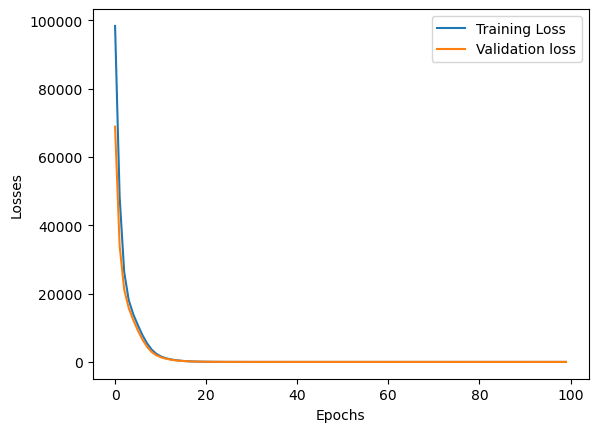

In [25]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss": valid_losses
})

plt.plot(loss_df["train_loss"],label="Training Loss")
plt.plot(loss_df["val_loss"],label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses" )

plt.legend()

In [27]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [31]:
# Evaluate our model
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds= model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds,y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 21.129032135009766
Testing MSE: 19.421630859375


In [32]:
from sklearn.metrics import r2_score
print("r^2 =",r2_score(y_test,test_preds))

r^2 = 0.9321264130963169
